# Clean KNN exploration

**Research question:** How do feature scaling and the number of neighbours \(k\)
affect KNN classification performance and its decision boundary?

This notebook calls the same plain functions that live in the `reproducible_knn/`
folder. The full experiment (including saving metrics) is also available without
Jupyter as:

```bash
python -m reproducible_knn.run
```


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import yaml
from sklearn.metrics import accuracy_score

from reproducible_knn.data import make_data, split_data
from reproducible_knn.model import choose_k, make_knn

# Works whether you started Jupyter in solution_repo/ or notebooks/
ROOT = Path.cwd()
if not (ROOT / "config.yaml").exists() and (ROOT.parent / "config.yaml").exists():
    ROOT = ROOT.parent


## Load settings from `config.yaml`

Numbers live in one file so you do not hunt through cells to change the seed or
the \(k\) grid.


In [2]:
with open(ROOT / "config.yaml") as f:
    cfg = yaml.safe_load(f)

print("seed =", cfg["seed"])
print("k_values =", cfg["k_values"])
print("use_scaling =", cfg["use_scaling"])


seed = 20240719
k_values = [1, 3, 5, 15, 31]
use_scaling = True


## Data: generate + stratified split

Same seed → same data and same split.


n_train=280, n_test=120


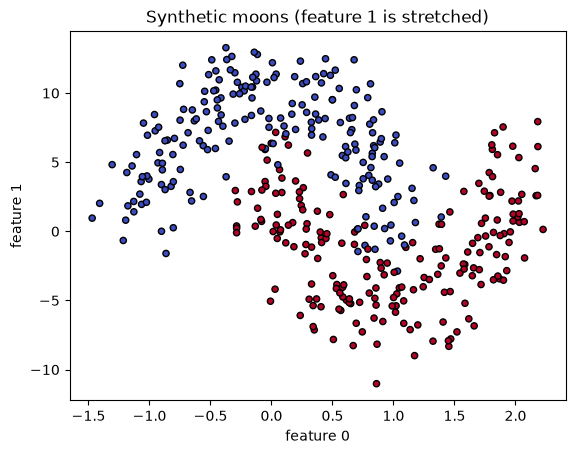

In [3]:
X, y = make_data(
    n_samples=cfg["n_samples"],
    noise=cfg["noise"],
    scale_factor=cfg["scale_factor"],
    seed=cfg["seed"],
)
X_train, X_test, y_train, y_test = split_data(
    X, y, test_size=cfg["test_size"], seed=cfg["seed"]
)

print(f"n_train={len(y_train)}, n_test={len(y_test)}")

fig, ax = plt.subplots()
ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=20)
ax.set_title("Synthetic moons (feature 1 is stretched)")
ax.set_xlabel("feature 0")
ax.set_ylabel("feature 1")
plt.show()


## Choose \(k\) with cross-validation on the **training** set only

Scaling (if enabled) lives inside a `Pipeline`, so each CV fold fits the scaler
on that fold's training rows only. The held-out test set is not used here.


In [ ]:
best_k, cv_results = choose_k(
    X_train,
    y_train,
    k_values=cfg["k_values"],
    use_scaling=cfg["use_scaling"],
    seed=cfg["seed"],
    cv_folds=cfg["cv_folds"],
)
display(cv_results)
print("best_k =", best_k)


## Fit the chosen model and score the test set **once**


In [ ]:
model = make_knn(k=best_k, use_scaling=cfg["use_scaling"])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("test accuracy =", float(accuracy_score(y_test, y_pred)))


## Optional: compare scaled vs unscaled

Change one flag and re-run selection. Do not use the test set to choose which
setting is better — look at CV accuracy on the training set.


In [ ]:
rows = []
for use_scaling in [False, True]:
    k, results = choose_k(
        X_train,
        y_train,
        k_values=cfg["k_values"],
        use_scaling=use_scaling,
        seed=cfg["seed"],
        cv_folds=cfg["cv_folds"],
    )
    rows.append(
        {
            "use_scaling": use_scaling,
            "best_k": k,
            "best_cv_accuracy": float(results.loc[0, "mean_cv_accuracy"]),
        }
    )

import pandas as pd

display(pd.DataFrame(rows))


## Reproduce without this notebook

From the project root:

```bash
python -m reproducible_knn.run
```

That writes `outputs/run/metrics.json`, a copy of the config, and two figures.
Run it twice with the same seed and compare the metrics files.
